# Loan Prediction Problem

Company wants to automate the loan eligibility process (real time) based on customer detail provided while filling online application form. These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History and others. To automate this process, they have given a problem to identify the customers segments, those are eligible for loan amount so that they can specifically target these customers. Here they have provided a partial data set.



Importing Necessary Libraries


In [1]:
# Data Wrangling 
import numpy as np
import pandas as pd 

# Data Visualisation 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

# Machine Learning Tools 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import Perceptron
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, mean_squared_error

## Read Data into the dataframe

In [2]:
train_data = pd.read_csv('../input/train.txt')
test_data = pd.read_csv('../input/test.txt')
combine = [train_data, test_data]

In [3]:
train_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
print(test_data.head())
test_sub = test_data.copy()
test_sub.head()

    Loan_ID Gender      ...      Credit_History Property_Area
0  LP001015   Male      ...                 1.0         Urban
1  LP001022   Male      ...                 1.0         Urban
2  LP001031   Male      ...                 1.0         Urban
3  LP001035   Male      ...                 NaN         Urban
4  LP001051   Male      ...                 1.0         Urban

[5 rows x 12 columns]


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


Start by converting the nominal variables to binary 

In [5]:
train_data['Loan_Status'] = train_data['Loan_Status'].map( {'Y' : 1, 'N' : 0} )
train_data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [6]:
train_data.describe(percentiles = [.31, .32 ])
# train_data.describe(percentiles = [.15, .2 ])

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,614.000000,614.000000,592.000000,600.00000,564.000000,614.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199,0.687296
std,6109.041673,2926.248369,85.587325,65.12041,0.364878,0.463973
min,150.000000,0.000000,9.000000,12.00000,0.000000,0.000000
31%,3083.000000,0.000000,109.210000,360.00000,1.000000,0.000000
32%,3100.480000,0.000000,110.000000,360.00000,1.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000,1.000000


In [7]:
train_data.describe(include = 'O')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area
count,614,601,611,599,614,582,614
unique,614,2,2,4,2,2,3
top,LP001744,Male,Yes,0,Graduate,No,Semiurban
freq,1,489,398,345,480,500,233


#### Inference

* Loan Applicant incomes range from 150 to 81000 
* Co applicant income 0 ( no - coapplicants ) to 41667. 
* Loan Amount ranges from 9 to 700 
* 69% of the people get their loans approved
* 85% of the people have their past credit guidelines met 
* More than half of the people are married ( 398 out of 611 ) 
* Most people are Males and Working in a company. 
* All IDs are unique and randomly alloted. They have no impact on the Loan_Status and can be dropped. 
* Less than half of the population work in semiurban areas but have the highest frequency of appearance. 

In [8]:
# Dropping Loan_ID
train_data.drop('Loan_ID', axis = 1, inplace = True)
test_data.drop('Loan_ID', axis = 1, inplace = True)
combine = [train_data, test_data]
train_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


## Data Wrangling

In [9]:
print(train_data.isnull().sum())
print('-' * 50)
print(test_data.isnull().sum())

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64
--------------------------------------------------
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64


There are plenty of missing values and some of them are categorical variables so we need to find relations between data and plot data to estimate the missing values more accurately. 

Let's look at the basic correlations in the data

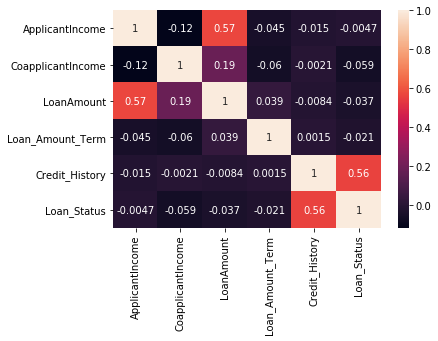

In [10]:
# Plotting a correlation heatmap
sns.heatmap(train_data.corr(), annot = True)

In [11]:
print(train_data[['Married', 'ApplicantIncome']].groupby('Married', as_index = False).median())
print('\n')
print(train_data[['Married', 'ApplicantIncome']].groupby('Married', as_index = False).mean())

  Married  ApplicantIncome
0      No           3750.0
1     Yes           3854.5


  Married  ApplicantIncome
0      No      4970.384977
1     Yes      5629.173367


In [12]:
print(train_data[['Married', 'CoapplicantIncome']].groupby('Married', as_index = False).median())

  Married  CoapplicantIncome
0      No                0.0
1     Yes             1625.0


We see that people with no co-applicants are in most cases not married. 

In [13]:
train_data[['Married', 'Gender']].groupby('Gender').count()

,Married
Gender,
Female,111
Male,487


For the married column, there are only 3 missing entries. Let's replace the data with income less than 5000 as unmarried and above 5000 as married. 

In [14]:
train_data[train_data['Married'].isnull()]


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
104,Male,NaN,NaN,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,1
228,Male,NaN,NaN,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,1
435,Female,NaN,NaN,Graduate,No,10047,0.0,NaN,240.0,1.0,Semiurban,1


Let's manuallly fill these values 

In [15]:
train_data.set_value(435, 'Married', 'Yes')
train_data.set_value(104, 'Married', 'Yes')
train_data.set_value(228, 'Married', 'No')

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  """Entry point for launching an IPython kernel.
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:3: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  This is separate from the ipykernel package so we can avoid doing imports until


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1
6,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,1
7,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,0
8,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,1
9,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,0


In [16]:
train_data[['Loan_Status', 'Gender']].groupby(['Gender']).mean()

,Loan_Status
Gender,
Female,0.669643
Male,0.693252


There is almost a similar chance of getting your loan approved irrespective of your gender. 


In [17]:
train_data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [18]:
train_data.Married.unique()

array(['No', 'Yes'], dtype=object)

In [19]:
train_data[['Married', 'Gender', 'Loan_Status']].groupby(['Married'], as_index = False).mean()

,Married,Loan_Status
0,No,0.630841
1,Yes,0.717500


Higher chance of loan approval if you're married. 

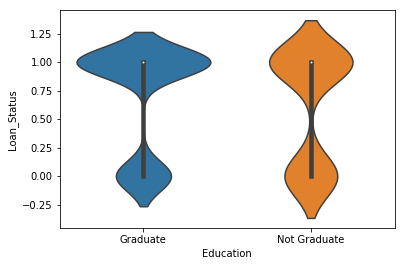

In [20]:
sns.violinplot(x = 'Education', y = 'Loan_Status', data = train_data)

In [21]:
train_data[['Property_Area', 'Loan_Status']].groupby(['Property_Area'], as_index = False).mean().sort_values(['Loan_Status'], ascending = False)

,Property_Area,Loan_Status
1,Semiurban,0.768240
2,Urban,0.658416
0,Rural,0.614525


Semi - Urban People have higher chances of Loan Approval

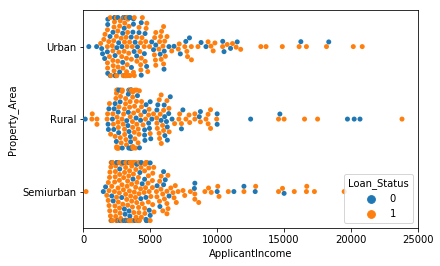

In [22]:
axes = plt.gca()
axes.set_xlim([0,25000])
sns.swarmplot(x = 'ApplicantIncome', y = 'Property_Area', data = train_data, hue = 'Loan_Status')

In [23]:
print(train_data.Dependents.unique())
train_data[['Dependents', 'Loan_Status']].groupby(['Dependents'], as_index = False).mean()

['0' '1' '2' '3+' nan]


,Dependents,Loan_Status
0,0,0.689855
1,1,0.647059
2,2,0.752475
3,3+,0.647059


In [24]:
train_data['Dependents'].dtype

dtype('O')

Let's also change the dependents data to make it numeric for further changes. We can have 3+ as 3

In [25]:
# Converting Married to nominal variables. 
combine = [train_data, test_data]
for dataset in combine: 
    dataset['Married'] = dataset['Married'].map({'Yes' : 1, 'No' : 0})
train_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,0,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,1,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,1,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,1,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,0,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [26]:
train_data[['Married', 'Gender', 'Education']].groupby(['Education', 'Married']).count()

Gender
Education    Married        
Graduate     0           166
             1           302
Not Graduate 0            45
             1            88

## Filling Missing Data


In [27]:
combine = [train_data, test_data]

In [28]:
train_data.isnull().sum()


Gender               13
Married               0
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

There are a number of dependent column values missing. Let's try and fill them. 

In [29]:
train_data[['Married', 'Dependents', 'Gender']].groupby(['Dependents', 'Gender'], as_index = False).mean() 

,Dependents,Gender,Married
0,0,Female,0.250000
1,0,Male,0.577519
2,1,Female,0.315789
3,1,Male,0.878049
4,2,Female,0.714286
5,2,Male,0.934783
6,3+,Female,0.000000
7,3+,Male,0.933333


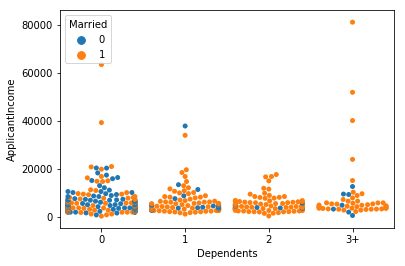

In [30]:
sns.swarmplot(x = 'Dependents', y = 'ApplicantIncome', hue = 'Married', data = train_data)

In [31]:
train_data[['Married', 'Dependents', 'ApplicantIncome']].groupby('Dependents').median()

,Married,ApplicantIncome
Dependents,,
0,1.0,3598.0
1,1.0,4051.5
2,1.0,4006.0
3+,1.0,4691.0


In [32]:
train_data[['Education', 'Dependents', 'Married']].groupby(['Dependents', 'Education'], as_index = False).count()

,Dependents,Education,Married
0,0,Graduate,275
1,0,Not Graduate,70
2,1,Graduate,81
3,1,Not Graduate,21
4,2,Graduate,77
5,2,Not Graduate,24
6,3+,Graduate,36
7,3+,Not Graduate,15


In [33]:
train_data[['Self_Employed', 'Dependents']].groupby('Dependents', as_index = False).count().pivot(columns = 'Self_Employed', index = 'Dependents')

Dependents
0
1
2
3+


In [34]:
train_data[['Property_Area', 'Dependents']].groupby(['Dependents'], as_index = False).count()

,Dependents,Property_Area
0,0,345
1,1,102
2,2,101
3,3+,51


In [35]:
train_data[['Gender', 'Dependents', 'ApplicantIncome']].groupby(['Dependents', 'Gender'], as_index = False).median()

,Dependents,Gender,ApplicantIncome
0,0,Female,3413.0
1,0,Male,3697.5
2,1,Female,4608.0
3,1,Male,3931.5
4,2,Female,3427.0
5,2,Male,4183.5
6,3+,Female,1830.0
7,3+,Male,4691.0


**Inference**
* We can see that the number of dependents are related to the marital status and their gender.  
* Graduates have more dependents. 
* People with huge applicant income have higher chances of having a dependent. 
* Self Employed People have more dependents

In [36]:
train_data[train_data['Dependents'].isnull()]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
102,Male,1,NaN,Graduate,No,13650,0.0,NaN,360.0,1.0,Urban,1
104,Male,1,NaN,Graduate,No,3816,754.0,160.0,360.0,1.0,Urban,1
120,Male,1,NaN,Graduate,No,5667,2667.0,180.0,360.0,1.0,Rural,1
226,Male,1,NaN,Not Graduate,Yes,4735,0.0,138.0,360.0,1.0,Urban,0
228,Male,0,NaN,Graduate,No,4758,0.0,158.0,480.0,1.0,Semiurban,1
293,Female,0,NaN,Graduate,No,5417,0.0,143.0,480.0,0.0,Urban,0
301,Male,1,NaN,Not Graduate,No,2875,1750.0,105.0,360.0,1.0,Semiurban,1
332,Male,0,NaN,Graduate,No,2833,0.0,71.0,360.0,1.0,Urban,1
335,Male,1,NaN,Graduate,Yes,5503,4490.0,70.0,NaN,1.0,Semiurban,1
346,Male,1,NaN,Not Graduate,No,3523,3230.0,152.0,360.0,0.0,Rural,0


In [37]:
train_data.groupby('Dependents')['Dependents'].count()

Dependents
0     345
1     102
2     101
3+     51
Name: Dependents, dtype: int64

In [38]:
# Individual Manual Changes 
train_data.set_value(102, 'Dependents','3+')
train_data.set_value(332, 'Dependents', '0')
train_data.set_value(335, 'Dependents', '2')
train_data.set_value(597, 'Dependents', '0')

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:3: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  This is separate from the ipykernel package so we can avoid doing imports until
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:4: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  after removing the cwd from sys.path.
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:5: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  """


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,0,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,1,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,1,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,1,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,0,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,Male,1,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1
6,Male,1,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,1
7,Male,1,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,0
8,Male,1,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,1
9,Male,1,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,0


In [39]:
for dataset in combine:   
    # For males
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] < 3683.5) & (dataset['Gender'] == 'Male'), 'Dependents'] = '0'
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] > 3683.5) & (dataset['ApplicantIncome'] <= 3931.5) & (dataset['Gender'] == 'Male'),'Dependents'] = '1'
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] > 3931.5) & (dataset['ApplicantIncome'] <= 4200.0) & (dataset['Gender'] == 'Male'),'Dependents'] = '2'
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] > 4200.0) & (dataset['Gender'] == 'Male'), 'Dependents'] = '3+'
    
    # For Females 
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] < 3416.0) & (dataset['Gender'] == 'Female'), 'Dependents'] = '0'
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] > 4608.0) & (dataset['ApplicantIncome'] <= 4200) & (dataset['Gender'] == 'Female'),'Dependents'] = '1'
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] > 3427.0) & (dataset['ApplicantIncome'] <= 4608.0) & (dataset['Gender'] == 'Female'),'Dependents'] = '2'
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] > 4200.0) & (dataset['Gender'] == 'Female'), 'Dependents'] = '3+'
train_data.isnull().sum()

Gender               13
Married               0
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [40]:
print(test_data.isnull().sum())
print("\n")
test_data[test_data['Dependents'].isnull()]

Gender               11
Married               0
Dependents            1
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64




,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
138,NaN,0,NaN,Graduate,No,3333,1250,110.0,360.0,1.0,Semiurban


A lot of genders are missing in the test and the train data. Let's simply replace them with the mode value. 


In [41]:
freq_gender = train_data.Gender.dropna().mode()[0]
freq_gender

'Male'

In [42]:
for dataset in combine: 
    dataset['Gender'] = dataset['Gender'].fillna(freq_gender)
    
train_data[['Gender', 'Loan_Status']].groupby('Gender', as_index = False).mean()

,Gender,Loan_Status
0,Female,0.669643
1,Male,0.691235


Let's run that set of code again so that all the values are filed. 

In [43]:
for dataset in combine:   
    # For males
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] < 3683.5) & (dataset['Gender'] == 'Male'), 'Dependents'] = '0'
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] > 3683.5) & (dataset['ApplicantIncome'] <= 3931.5) & (dataset['Gender'] == 'Male'),'Dependents'] = '1'
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] > 3931.5) & (dataset['ApplicantIncome'] <= 4200.0) & (dataset['Gender'] == 'Male'),'Dependents'] = '2'
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] > 4200.0) & (dataset['Gender'] == 'Male'), 'Dependents'] = '3+'
    
    # For Females 
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] < 3416.0) & (dataset['Gender'] == 'Female'), 'Dependents'] = '0'
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] > 4608.0) & (dataset['ApplicantIncome'] <= 4200) & (dataset['Gender'] == 'Female'),'Dependents'] = '1'
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] > 3427.0) & (dataset['ApplicantIncome'] <= 4608.0) & (dataset['Gender'] == 'Female'),'Dependents'] = '2'
    dataset.loc[(dataset['Dependents'].isnull()) & (dataset['ApplicantIncome'] > 4200.0) & (dataset['Gender'] == 'Female'), 'Dependents'] = '3+'
train_data.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [44]:
for dataset in combine: 
    dataset.loc[(dataset['Self_Employed'].isnull()) & (dataset['Education'] == 'Not Graduate'), 'Self_Employed'] = 'No'
train_data.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        26
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

## Conversion of Categorigal Variables

Convert Dependents and Self - Employed People to binary

In [45]:
train_data['Dependents'] = train_data['Dependents'].map( {'0' : 0, '1' : 1, '2' : 2, '3+' : 3} )
train_data.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,0,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,1,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,1,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,1,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,0,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,Male,1,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1
6,Male,1,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,1
7,Male,1,3,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,0
8,Male,1,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,1
9,Male,1,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,0


In [46]:
test_data['Dependents'] = test_data['Dependents'].map( {'0' : 0, '1' : 1, '2' : 2, '3+' : 3} )
test_data.head(10)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,1,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,Male,1,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,Male,1,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,Male,1,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,Male,0,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban
5,Male,1,0,Not Graduate,Yes,2165,3422,152.0,360.0,1.0,Urban
6,Female,0,1,Not Graduate,No,2226,0,59.0,360.0,1.0,Semiurban
7,Male,1,2,Not Graduate,No,3881,0,147.0,360.0,0.0,Rural
8,Male,1,2,Graduate,NaN,13633,0,280.0,240.0,1.0,Urban
9,Male,0,0,Not Graduate,No,2400,2400,123.0,360.0,1.0,Semiurban


#### Filling Self employed Category 

In [47]:
train_data[['ApplicantIncome', 'Self_Employed']].groupby('Self_Employed', as_index = False).median()

,Self_Employed,ApplicantIncome
0,No,3698
1,Yes,5809


In [48]:
combine = [train_data, test_data]
for dataset in combine: 
    dataset['Self_Employed'] = dataset['Self_Employed'].dropna(0).map({'No' : 0, 'Yes' : 1})
train_data.head(20)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,0,0,Graduate,0.0,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,1,1,Graduate,0.0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,1,0,Graduate,1.0,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,1,0,Not Graduate,0.0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,0,0,Graduate,0.0,6000,0.0,141.0,360.0,1.0,Urban,1
5,Male,1,2,Graduate,1.0,5417,4196.0,267.0,360.0,1.0,Urban,1
6,Male,1,0,Not Graduate,0.0,2333,1516.0,95.0,360.0,1.0,Urban,1
7,Male,1,3,Graduate,0.0,3036,2504.0,158.0,360.0,0.0,Semiurban,0
8,Male,1,2,Graduate,0.0,4006,1526.0,168.0,360.0,1.0,Urban,1
9,Male,1,1,Graduate,0.0,12841,10968.0,349.0,360.0,1.0,Semiurban,0


In [49]:
train_data[['Self_Employed', 'Gender']].groupby('Gender', as_index = False).mean()

,Gender,Self_Employed
0,Female,0.141509
1,Male,0.139004


In [50]:
train_data[['Self_Employed', 'Education']].groupby('Education', as_index = False).mean()

,Education,Self_Employed
0,Graduate,0.143172
1,Not Graduate,0.126866


In [51]:
train_data[['Self_Employed', 'Dependents']].groupby('Self_Employed', as_index = False).mean()

,Self_Employed,Dependents
0,0.0,0.762846
1,1.0,0.951220


In [52]:
train_data[['Self_Employed', 'Married', 'Gender']].groupby(['Married', 'Gender'], as_index = False).mean()

,Married,Gender,Self_Employed
0,0,Female,0.146667
1,0,Male,0.132812
2,1,Female,0.129032
3,1,Male,0.141243


We will use income as a means of replacing the values

In [53]:
for dataset in combine:
    dataset.loc[(dataset['Self_Employed'].isnull()) & (dataset['ApplicantIncome'] < 5809), 'Self_Employed'] = 0
    dataset.loc[(dataset['Self_Employed'].isnull()) & (dataset['ApplicantIncome'] >= 5809), 'Self_Employed'] = 1
train_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,0,0,Graduate,0.0,5849,0.0,NaN,360.0,1.0,Urban,1
1,Male,1,1,Graduate,0.0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,1,0,Graduate,1.0,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,1,0,Not Graduate,0.0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,0,0,Graduate,0.0,6000,0.0,141.0,360.0,1.0,Urban,1


#### Filling Loan Amount

In [54]:
train_data.describe()


,Married,Dependents,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status
count,614.000000,614.000000,614.000000,614.000000,614.000000,592.000000,600.00000,564.000000,614.000000
mean,0.651466,0.786645,0.140065,5403.459283,1621.245798,146.412162,342.00000,0.842199,0.687296
std,0.476895,1.035307,0.347338,6109.041673,2926.248369,85.587325,65.12041,0.364878,0.463973
min,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.00000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,2877.500000,0.000000,100.000000,360.00000,1.000000,0.000000
50%,1.000000,0.000000,0.000000,3812.500000,1188.500000,128.000000,360.00000,1.000000,1.000000
75%,1.000000,2.000000,0.000000,5795.000000,2297.250000,168.000000,360.00000,1.000000,1.000000
max,1.000000,3.000000,1.000000,81000.000000,41667.000000,700.000000,480.00000,1.000000,1.000000


Simply taking mean has an std of 65. Let's try to reduce that with groups. 

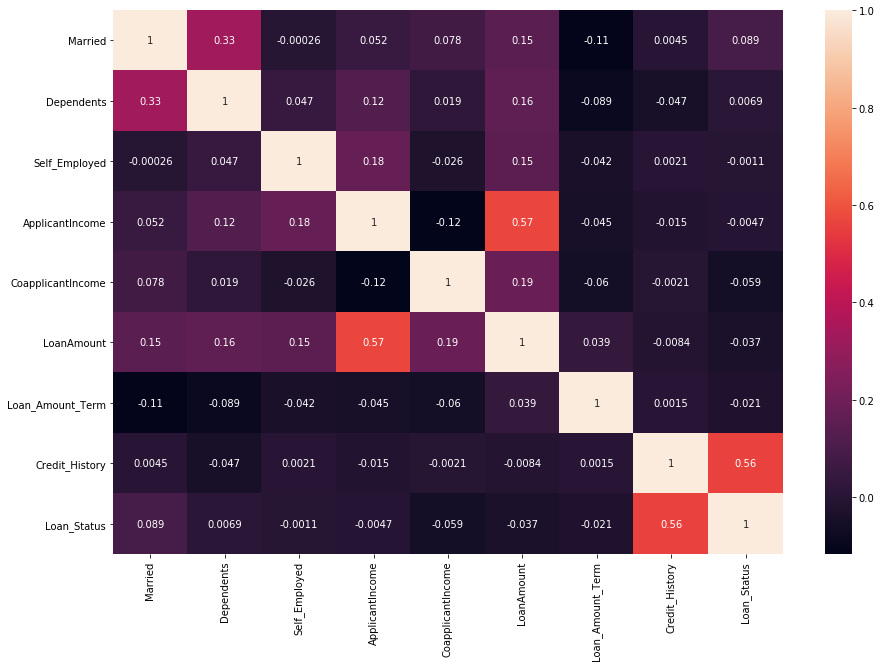

In [55]:
plt.figure(figsize = (15, 10))
sns.heatmap(train_data.corr(), annot = True)

We can see that Loan ammount depends on applicant income. Let's make income an ordinal variable. 

In [56]:
# train_data['IncomeBand'] = pd.cut(train_data['Loan_Amount_Term'], 7)
# train_data[['IncomeBand', 'Loan_Status']].groupby(['IncomeBand'], as_index = False).mean()

#### Convert the variables to ordinal ( Applicant Income ) 

In [57]:
# for dataset in combine:    
#     dataset.loc[ dataset['ApplicantIncome'] <= 11700.0, 'ApplicantIncome'] = 0
#     dataset.loc[(dataset['ApplicantIncome'] > 11700.0) & (dataset['ApplicantIncome'] <= 23250.0), 'ApplicantIncome'] = 1
#     dataset.loc[(dataset['ApplicantIncome'] > 23250.0) & (dataset['ApplicantIncome'] <= 34800.0), 'ApplicantIncome'] = 2
#     dataset.loc[(dataset['ApplicantIncome'] > 34800.0) & (dataset['ApplicantIncome'] <= 46350.0), 'ApplicantIncome'] = 3
#     dataset.loc[(dataset['ApplicantIncome'] > 46350.0) & (dataset['ApplicantIncome'] <= 57900.0), 'ApplicantIncome'] = 4
#     dataset.loc[(dataset['ApplicantIncome'] > 57900.0) & (dataset['ApplicantIncome'] <= 69450.0), 'ApplicantIncome'] = 5
#     dataset.loc[ dataset['ApplicantIncome'] > 69450, 'ApplicantIncome'] = 7
# train_data.tail(20)

In [58]:
train_data['LoanAmount'].fillna(train_data['LoanAmount'].median(), inplace = True)
train_data['Loan_Amount_Term'].fillna(train_data['Loan_Amount_Term'].median(), inplace = True)
test_data['LoanAmount'].fillna(train_data['LoanAmount'].median(), inplace = True)
test_data['Loan_Amount_Term'].fillna(train_data['Loan_Amount_Term'].median(), inplace = True)

In [59]:
train_data.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term      0
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [60]:
train_data[['Credit_History', 'Education']].groupby('Education', as_index = False).mean()

,Education,Credit_History
0,Graduate,0.857788
1,Not Graduate,0.785124


In [61]:
train_data[['Credit_History', 'ApplicantIncome']].groupby('Credit_History', as_index = False).mean()

,Credit_History,ApplicantIncome
0,0.0,5679.438202
1,1.0,5426.526316


In [62]:
import random
for dataset in combine:   
    # For males
    dataset.loc[(dataset['Credit_History'].isnull()) & (dataset['ApplicantIncome'] < 3683.5) & (dataset['Gender'] == 'Male'), 'Credit_History'] = random.randint(0,1)
    dataset.loc[(dataset['Credit_History'].isnull()) & (dataset['ApplicantIncome'] > 3683.5) & (dataset['ApplicantIncome'] <= 3931.5) & (dataset['Gender'] == 'Male'),'Credit_History'] = random.randint(0,1)
    dataset.loc[(dataset['Credit_History'].isnull()) & (dataset['ApplicantIncome'] > 3931.5) & (dataset['ApplicantIncome'] <= 4200.0) & (dataset['Gender'] == 'Male'),'Credit_History'] = random.randint(0,1)
    dataset.loc[(dataset['Credit_History'].isnull()) & (dataset['ApplicantIncome'] > 4200.0) & (dataset['Gender'] == 'Male'), 'Credit_History'] = random.randint(0,1)
    
    # For Females 
    dataset.loc[(dataset['Credit_History'].isnull()) & (dataset['ApplicantIncome'] < 3416.0) & (dataset['Gender'] == 'Female'), 'Dependents'] = random.randint(0,1)
    dataset.loc[(dataset['Credit_History'].isnull()) & (dataset['ApplicantIncome'] > 4608.0) & (dataset['ApplicantIncome'] <= 4200) & (dataset['Gender'] == 'Female'),'Credit_History'] = random.randint(0,1)
    dataset.loc[(dataset['Credit_History'].isnull()) & (dataset['ApplicantIncome'] > 3427.0) & (dataset['ApplicantIncome'] <= 4608.0) & (dataset['Gender'] == 'Female'),'Credit_History'] = random.randint(0,1)
    dataset.loc[(dataset['Credit_History'].isnull()) & (dataset['ApplicantIncome'] > 4200.0) & (dataset['Gender'] == 'Female'), 'Credit_History'] = random.randint(0,1)
train_data.head(20)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,0,0,Graduate,0.0,5849,0.0,128.0,360.0,1.0,Urban,1
1,Male,1,1,Graduate,0.0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,1,0,Graduate,1.0,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,1,0,Not Graduate,0.0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,0,0,Graduate,0.0,6000,0.0,141.0,360.0,1.0,Urban,1
5,Male,1,2,Graduate,1.0,5417,4196.0,267.0,360.0,1.0,Urban,1
6,Male,1,0,Not Graduate,0.0,2333,1516.0,95.0,360.0,1.0,Urban,1
7,Male,1,3,Graduate,0.0,3036,2504.0,158.0,360.0,0.0,Semiurban,0
8,Male,1,2,Graduate,0.0,4006,1526.0,168.0,360.0,1.0,Urban,1
9,Male,1,1,Graduate,0.0,12841,10968.0,349.0,360.0,1.0,Semiurban,0


This is done just to increase the randomness

In [63]:
train_data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       6
Property_Area        0
Loan_Status          0
dtype: int64

In [64]:
train_data[train_data['Credit_History'].isnull()]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
198,Female,1,0,Graduate,0.0,3416,2816.0,113.0,360.0,NaN,Semiurban,1
323,Female,0,0,Graduate,0.0,3166,2985.0,132.0,360.0,NaN,Rural,1
473,Female,0,0,Graduate,1.0,2500,0.0,93.0,360.0,NaN,Urban,1
544,Female,1,0,Not Graduate,0.0,3017,663.0,102.0,360.0,NaN,Semiurban,1
556,Female,0,0,Graduate,0.0,2667,1625.0,84.0,360.0,NaN,Urban,1
600,Female,0,0,Graduate,0.0,416,41667.0,350.0,180.0,NaN,Urban,0


In [65]:
train_data.set_value(198, 'Credit_History', 1) 
train_data.set_value(323, 'Credit_History', 1) 
train_data.set_value(473, 'Credit_History', 1) 
train_data.set_value(544, 'Credit_History', 0) 
train_data.set_value(556, 'Credit_History', 0) 
train_data.set_value(600, 'Credit_History', 0) 

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  """Entry point for launching an IPython kernel.
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:3: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  This is separate from the ipykernel package so we can avoid doing imports until
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:4: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  after removing the cwd from sys.path.
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:5: Futur

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,0,0,Graduate,0.0,5849,0.0,128.0,360.0,1.0,Urban,1
1,Male,1,1,Graduate,0.0,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,1,0,Graduate,1.0,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,1,0,Not Graduate,0.0,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,0,0,Graduate,0.0,6000,0.0,141.0,360.0,1.0,Urban,1
5,Male,1,2,Graduate,1.0,5417,4196.0,267.0,360.0,1.0,Urban,1
6,Male,1,0,Not Graduate,0.0,2333,1516.0,95.0,360.0,1.0,Urban,1
7,Male,1,3,Graduate,0.0,3036,2504.0,158.0,360.0,0.0,Semiurban,0
8,Male,1,2,Graduate,0.0,4006,1526.0,168.0,360.0,1.0,Urban,1
9,Male,1,1,Graduate,0.0,12841,10968.0,349.0,360.0,1.0,Semiurban,0


In [66]:
train_data.isnull().any().any()

False

In [67]:
test_data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       3
Property_Area        0
dtype: int64

In [68]:
test_data[test_data['Credit_History'].isnull()]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
177,Female,0,0,Graduate,0.0,2918,0,65.0,360.0,NaN,Rural
259,Female,0,0,Graduate,0.0,1850,4583,81.0,360.0,NaN,Rural
336,Female,0,0,Not Graduate,0.0,3015,2000,145.0,360.0,NaN,Urban


In [69]:
test_data.set_value(177, 'Credit_History', 1) 
test_data.set_value(259, 'Credit_History', 0) 
test_data.set_value(336, 'Credit_History', 1) 

/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:1: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  """Entry point for launching an IPython kernel.
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:2: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  
/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:3: FutureWarning: set_value is deprecated and will be removed in a future release. Please use .at[] or .iat[] accessors instead
  This is separate from the ipykernel package so we can avoid doing imports until


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,1,0,Graduate,0.0,5720,0,110.0,360.0,1.0,Urban
1,Male,1,1,Graduate,0.0,3076,1500,126.0,360.0,1.0,Urban
2,Male,1,2,Graduate,0.0,5000,1800,208.0,360.0,1.0,Urban
3,Male,1,2,Graduate,0.0,2340,2546,100.0,360.0,1.0,Urban
4,Male,0,0,Not Graduate,0.0,3276,0,78.0,360.0,1.0,Urban
5,Male,1,0,Not Graduate,1.0,2165,3422,152.0,360.0,1.0,Urban
6,Female,0,1,Not Graduate,0.0,2226,0,59.0,360.0,1.0,Semiurban
7,Male,1,2,Not Graduate,0.0,3881,0,147.0,360.0,0.0,Rural
8,Male,1,2,Graduate,1.0,13633,0,280.0,240.0,1.0,Urban
9,Male,0,0,Not Graduate,0.0,2400,2400,123.0,360.0,1.0,Semiurban


In [70]:
print(train_data.isnull().any().any())
print(test_data.isnull().any().any())

False
False


### Conversion of Categorical variables

In [71]:
combine = [train_data, test_data]
for dataset in combine: 
    dataset['Education'] = dataset['Education'].map( {'Graduate' : 1, 'Not Graduate' : 0} )
    dataset['Property_Area'] = dataset['Property_Area'].map( {'Rural' : 0, 'Urban' : 2, 'Semiurban' : 1} )
train_data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,0,0,1,0.0,5849,0.0,128.0,360.0,1.0,2,1
1,Male,1,1,1,0.0,4583,1508.0,128.0,360.0,1.0,0,0
2,Male,1,0,1,1.0,3000,0.0,66.0,360.0,1.0,2,1
3,Male,1,0,0,0.0,2583,2358.0,120.0,360.0,1.0,2,1
4,Male,0,0,1,0.0,6000,0.0,141.0,360.0,1.0,2,1


In [72]:
gender = pd.get_dummies(train_data['Gender'])
train_data = pd.concat([train_data, gender], axis = 1)
train_data.drop('Gender', axis = 1, inplace = True)
train_data.head()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Female,Male
0,0,0,1,0.0,5849,0.0,128.0,360.0,1.0,2,1,0,1
1,1,1,1,0.0,4583,1508.0,128.0,360.0,1.0,0,0,0,1
2,1,0,1,1.0,3000,0.0,66.0,360.0,1.0,2,1,0,1
3,1,0,0,0.0,2583,2358.0,120.0,360.0,1.0,2,1,0,1
4,0,0,1,0.0,6000,0.0,141.0,360.0,1.0,2,1,0,1


In [73]:
gender = pd.get_dummies(test_data['Gender'])
test_data = pd.concat([test_data, gender], axis = 1)
test_data.drop('Gender', axis = 1, inplace = True)
test_data.head()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Female,Male
0,1,0,1,0.0,5720,0,110.0,360.0,1.0,2,0,1
1,1,1,1,0.0,3076,1500,126.0,360.0,1.0,2,0,1
2,1,2,1,0.0,5000,1800,208.0,360.0,1.0,2,0,1
3,1,2,1,0.0,2340,2546,100.0,360.0,1.0,2,0,1
4,0,0,0,0.0,3276,0,78.0,360.0,1.0,2,0,1


In [74]:
train_data = train_data.astype(int)
train_data.dtypes

Married              int64
Dependents           int64
Education            int64
Self_Employed        int64
ApplicantIncome      int64
CoapplicantIncome    int64
LoanAmount           int64
Loan_Amount_Term     int64
Credit_History       int64
Property_Area        int64
Loan_Status          int64
Female               int64
Male                 int64
dtype: object

In [75]:
train_data['LoanBand'] = pd.cut(train_data['LoanAmount'], 4)
train_data[['LoanBand', 'Loan_Status']].groupby('LoanBand').mean()

,Loan_Status
LoanBand,
"(8.309, 181.75]",0.694332
"(181.75, 354.5]",0.653465
"(354.5, 527.25]",0.642857
"(527.25, 700.0]",0.800000


In [76]:
for dataset in combine:    
    dataset.loc[ dataset['LoanAmount'] <= 181.75, 'LoanAmount'] = 0
    dataset.loc[(dataset['LoanAmount'] > 181.75) & (dataset['LoanAmount'] <= 354.50), 'LoanAmount'] = 1
    dataset.loc[(dataset['LoanAmount'] > 354.50) & (dataset['LoanAmount'] <= 527.25), 'LoanAmount'] = 2
    dataset.loc[ dataset['LoanAmount'] > 700.00, 'LoanAmount'] = 3
train_data.drop('LoanBand', axis = 1, inplace = True)
train_data.head()

,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Female,Male
0,0,0,1,0,5849,0,128,360,1,2,1,0,1
1,1,1,1,0,4583,1508,128,360,1,0,0,0,1
2,1,0,1,1,3000,0,66,360,1,2,1,0,1
3,1,0,0,0,2583,2358,120,360,1,2,1,0,1
4,0,0,1,0,6000,0,141,360,1,2,1,0,1


## Building our models
Let's collect our splits

In [77]:
X_train = train_data.drop('Loan_Status', axis = 1)
y_train = train_data['Loan_Status']
X_test = test_data.copy()
print(X_train.shape, y_train.shape, X_test.shape)

(614, 12) (614,) (367, 12)


Logistic Regression

In [78]:
# Logistic Regression 

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
acc_log = round(logreg.score(X_train, y_train) * 100, 2)
acc_log

/opt/conda/lib/python3.6/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


79.48

In [79]:
coeff_data = pd.DataFrame(train_data.columns.delete(0))
coeff_data.columns = ['Feature']
coeff_data['Correlation'] = pd.Series(logreg.coef_[0])
coeff_data.sort_values(by = 'Correlation', ascending = False)

,Feature,Correlation
8,Property_Area,2.354526e+00
0,Dependents,5.871318e-01
2,Self_Employed,2.012082e-01
9,Loan_Status,8.472410e-02
4,CoapplicantIncome,-1.808659e-07
5,LoanAmount,-4.500448e-05
6,Loan_Amount_Term,-3.955428e-04
7,Credit_History,-2.020259e-03
1,Education,-3.593499e-02
3,ApplicantIncome,-6.407098e-02


In [80]:
# Support vector machines 
svc = SVC()
svc.fit(X_train, y_train)
Y_pred = svc.predict(X_test)
acc_svc = round(svc.score(X_train, y_train) * 100, 2)
acc_svc

/opt/conda/lib/python3.6/site-packages/sklearn/svm/base.py:193: FutureWarning: The default value of gamma will change from 'auto' to 'scale' in version 0.22 to account better for unscaled features. Set gamma explicitly to 'auto' or 'scale' to avoid this warning.
  "avoid this warning.", FutureWarning)


100.0

In [81]:
values = {}
for val in range(1, 51):
    knn = KNeighborsClassifier(n_neighbors = val)
    knn.fit(X_train, y_train)
    Y_pred = knn.predict(X_test)
    acc = round(knn.score(X_train, y_train) * 100, 2)
    values[val] = acc

Let's plot these values 

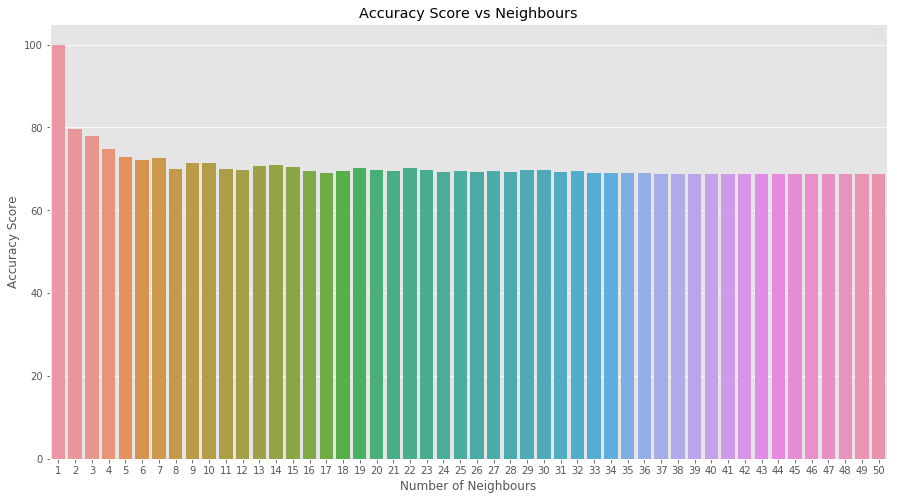

In [82]:
x_values, y_values = [], []
for val in values: 
    x_values.append(val)
    y_values.append(values[val])
from matplotlib import style
style.use('ggplot')
plt.figure(figsize = (15,8))
plt.title('Accuracy Score vs Neighbours')
plt.xlabel('Number of Neighbours')
plt.ylabel('Accuracy Score')
plt.legend()
sns.barplot(x = x_values, y = y_values)

In [83]:
acc_knn = 0
for val in values:
    if values[val] > acc_knn: 
        acc_knn = values[val]
acc_knn

100.0

In [84]:
# Gaussian Naive Bayes

gaussian = GaussianNB()
gaussian.fit(X_train, y_train)
Y_pred = gaussian.predict(X_test)
acc_gaussian = round(gaussian.score(X_train, y_train) * 100, 2)
acc_gaussian

78.5

In [85]:
# Perceptron

perceptron = Perceptron()
perceptron.fit(X_train, y_train)
Y_pred = perceptron.predict(X_test)
acc_perceptron = round(perceptron.score(X_train, y_train) * 100, 2)
acc_perceptron

39.41

In [86]:
# Linear SVC

linear_svc = LinearSVC()
linear_svc.fit(X_train, y_train)
Y_pred = linear_svc.predict(X_test)
acc_linear_svc = round(linear_svc.score(X_train, y_train) * 100, 2)
acc_linear_svc

/opt/conda/lib/python3.6/site-packages/sklearn/svm/base.py:929: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  "the number of iterations.", ConvergenceWarning)


68.73

In [87]:
# Stochastic Gradient Descent

sgd = SGDClassifier()
sgd.fit(X_train, y_train)
Y_pred = sgd.predict(X_test)
acc_sgd = round(sgd.score(X_train, y_train) * 100, 2)
acc_sgd

49.02

In [88]:
# Decision Tree

decision_tree = DecisionTreeClassifier(max_depth = 7)
decision_tree.fit(X_train, y_train)
Y_pred = decision_tree.predict(X_test)
acc_decision_tree = round(decision_tree.score(X_train, y_train) * 100, 2)
acc_decision_tree

87.46

In [89]:
# Random Forest

random_forest = RandomForestClassifier(n_estimators = 10)
random_forest.fit(X_train, y_train)
y_pred = random_forest.predict(X_test)
random_forest.score(X_train, y_train)
acc_random_forest = round(random_forest.score(X_train, y_train) * 100, 2)
acc_random_forest

98.05

In [90]:
pred_values = pd.DataFrame({
    'Model': ['Support Vector Machines', 'KNN', 'Logistic Regression', 
              'Random Forest', 'Naive Bayes', 'Perceptron', 
              'Stochastic Gradient Decent', 'Linear SVC', 
              'Decision Tree'],
    'Score': [acc_svc, acc_knn, acc_log, 
              acc_random_forest, acc_gaussian, acc_perceptron, 
              acc_sgd, acc_linear_svc, acc_decision_tree]})
pred_values.sort_values(by='Score', ascending=False)

,Model,Score
0,Support Vector Machines,100.00
1,KNN,100.00
3,Random Forest,98.05
8,Decision Tree,87.46
2,Logistic Regression,79.48
4,Naive Bayes,78.50
7,Linear SVC,68.73
6,Stochastic Gradient Decent,49.02
5,Perceptron,39.41


In [91]:
submission = pd.DataFrame({
        "Loan_ID": test_sub["Loan_ID"],
        "Loan_Status": y_pred
    })


In [92]:
submission['Loan_Status'].replace(0, 'N',inplace=True) 
submission['Loan_Status'].replace(1, 'Y',inplace=True)


In [93]:
submission.to_csv('submission_loan.csv', index=False)